# Assignment 4 - "Deep Learning Final Project" (15 p)


## Assignment 4-1: Implementation Plan for Deep Learning and Selection of Dataset (3 points)

The dataset comes from the domain of AI-generated vs. human-written text classification. This is an important topic today because large language models like ChatGPT produce text that looks very similar to human writing. The goal is to detect the subtle differences in writing style, structure, and language patterns. This makes the dataset suitable for deep learning, since the problem involves natural language and long text sequences, which models like LSTM, CNN, GCU, and Transformers are designed to handle.

In [1]:
import re
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.layers import (
    Input, Embedding, Dense, Dropout,
    LSTM, Bidirectional, Conv1D,
    GlobalMaxPooling1D, GlobalAveragePooling1D
)

from tensorflow.keras.layers import (
    LayerNormalization, MultiHeadAttention, Add
)

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam


In [2]:
import time

def train_with_timer(model, X, y, **kwargs):
    """Trains a model while recording runtime."""
    start = time.time()
    history = model.fit(X, y, **kwargs)
    end = time.time()
    runtime = end - start
    print(f"\nTraining time: {runtime:.2f} seconds")
    return history, runtime


In [3]:
# Load dataset
df = pd.read_csv("ai_human_10k.csv")

# Show first 5 rows
df.head()


,text,generated
0,"""Cell phones"", for the main statement I must e...",0.0
1,Changing the election to a vote of popularity ...,0.0
2,"When it comes to compensation, college graduat...",1.0
3,I think that the use oi this technology to rea...,0.0
4,**Cars are a huge part of our lives. We use th...,1.0


In [4]:
# Dataset shape
print("Dataset shape:", df.shape)

# Column names and types
print("\nColumn info:")
print(df.info())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())


Dataset shape: (10000, 2)

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   text       10000 non-null  object 
 1   generated  10000 non-null  float64
dtypes: float64(1), object(1)
memory usage: 156.4+ KB
None

Missing values:
text         0
generated    0
dtype: int64


Class distribution:
generated
0    6276
1    3724
Name: count, dtype: int64


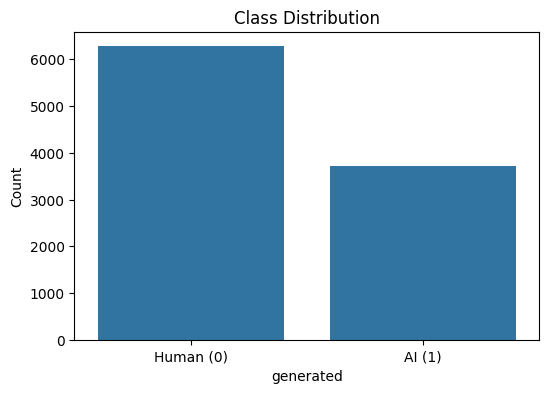

In [5]:
# Convert float label to integer
df['generated'] = df['generated'].astype(int)

# Class distribution
class_counts = df['generated'].value_counts()
print("Class distribution:")
print(class_counts)

# Plot class distribution
plt.figure(figsize=(6,4))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.xticks([0,1], ['Human (0)', 'AI (1)'])
plt.title("Class Distribution")
plt.ylabel("Count")
plt.show()


In [6]:
# Create text length features
df["char_count"] = df["text"].apply(len)
df["word_count"] = df["text"].apply(lambda x: len(str(x).split()))

df[["text", "char_count", "word_count"]].head()


,text,char_count,word_count
0,"""Cell phones"", for the main statement I must e...",2404,411
1,Changing the election to a vote of popularity ...,1736,285
2,"When it comes to compensation, college graduat...",1125,190
3,I think that the use oi this technology to rea...,3050,505
4,**Cars are a huge part of our lives. We use th...,2111,351


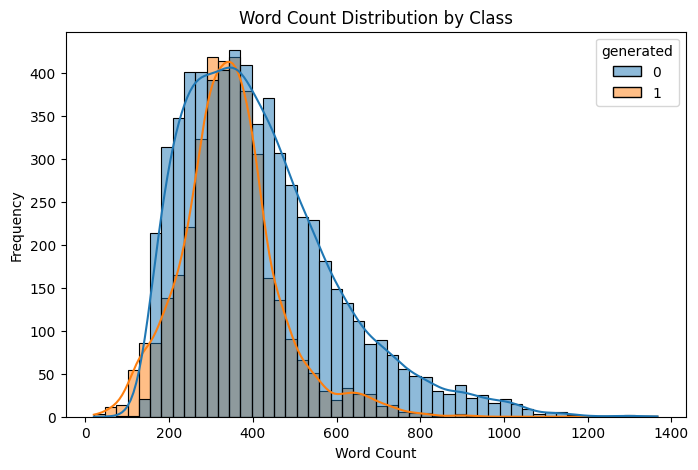

In [7]:
# Visualize word length distribution
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="word_count", hue="generated", bins=50, kde=True)
plt.title("Word Count Distribution by Class")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()


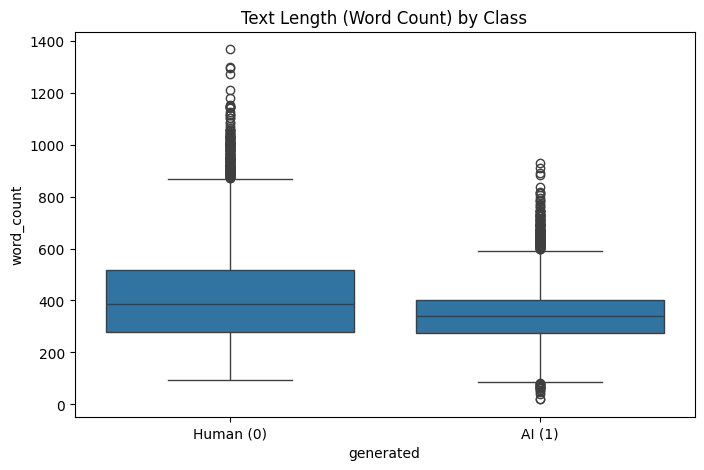

In [8]:
# compare length difference
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="generated", y="word_count")
plt.xticks([0,1], ["Human (0)", "AI (1)"])
plt.title("Text Length (Word Count) by Class")
plt.show()


In [9]:
# clean the text 

def clean_text(s):
    s = str(s)
    s = re.sub(r"\*\*+", " ", s)               # remove markdown bold (***)
    s = re.sub(r"[\"']", " ", s)               # remove quotes " and '
    s = re.sub(r"<.*?>", " ", s)               # remove HTML tags
    s = re.sub(r"[^0-9A-Za-zÀ-ÖØ-öø-ÿ.,;:()?!\- ]+", " ", s)  # keep punctuation
    s = re.sub(r"\s+", " ", s)                 # normalize whitespace
    s = s.lower().strip()
    return s

df["clean_text"] = df["text"].apply(clean_text)

df[["text", "clean_text"]].head()


,text,clean_text
0,"""Cell phones"", for the main statement I must e...","cell phones , for the main statement i must ev..."
1,Changing the election to a vote of popularity ...,changing the election to a vote of popularity ...
2,"When it comes to compensation, college graduat...","when it comes to compensation, college graduat..."
3,I think that the use oi this technology to rea...,i think that the use oi this technology to rea...
4,**Cars are a huge part of our lives. We use th...,cars are a huge part of our lives. we use them...


In [10]:
# Target
y = df["generated"].values

# Train/test split (80/20) — return indices for numeric features
X_train_text_raw, X_test_text_raw, y_train, y_test, train_idx, test_idx = train_test_split(
    df["clean_text"].values,
    y,
    np.arange(len(df)),
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train samples:", len(X_train_text_raw))
print("Test samples :", len(X_test_text_raw))


Train samples: 8000
Test samples : 2000


In [11]:
MAX_NUM_WORDS = 20000
MAX_LEN = 500

tokenizer = Tokenizer(num_words=MAX_NUM_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text_raw)   # tokenizer train only

# Convert to sequences
train_sequences = tokenizer.texts_to_sequences(X_train_text_raw)
test_sequences = tokenizer.texts_to_sequences(X_test_text_raw)

# Pad
X_text_train = pad_sequences(train_sequences, maxlen=MAX_LEN, padding="post")
X_text_test  = pad_sequences(test_sequences,  maxlen=MAX_LEN, padding="post")

vocab_size = min(MAX_NUM_WORDS, len(tokenizer.word_index) + 1)

print("Vocab size used:", vocab_size)
print("Train padded shape:", X_text_train.shape)
print("Test padded shape :", X_text_test.shape)


Vocab size used: 20000
Train padded shape: (8000, 500)
Test padded shape : (2000, 500)


In [12]:
# Rebuild numeric features
df["char_count"] = df["clean_text"].apply(len)
df["word_count"] = df["clean_text"].apply(lambda x: len(x.split()))
df["avg_word_len"] = df.apply(lambda r: (r["char_count"] / r["word_count"]) if r["word_count"]>0 else 0, axis=1)
df["sentence_count"] = df["clean_text"].apply(lambda x: max(1, x.count('.') + x.count('!') + x.count('?')))
df["punct_ratio"] = df["clean_text"].apply(lambda x: sum(ch in '.,;:!?' for ch in x) / max(1, len(x)))


In [13]:
# Numeric features split using indices

num_cols = ["char_count", "word_count", "avg_word_len", "sentence_count", "punct_ratio"]
X_num = df[num_cols].values

# Proper split (no leakage)
X_num_train = X_num[train_idx]
X_num_test  = X_num[test_idx]

# Scale after split
scaler = StandardScaler()
X_num_train = scaler.fit_transform(X_num_train)
X_num_test = scaler.transform(X_num_test)

print("Numeric train shape:", X_num_train.shape)
print("Numeric test shape :", X_num_test.shape)


Numeric train shape: (8000, 5)
Numeric test shape : (2000, 5)


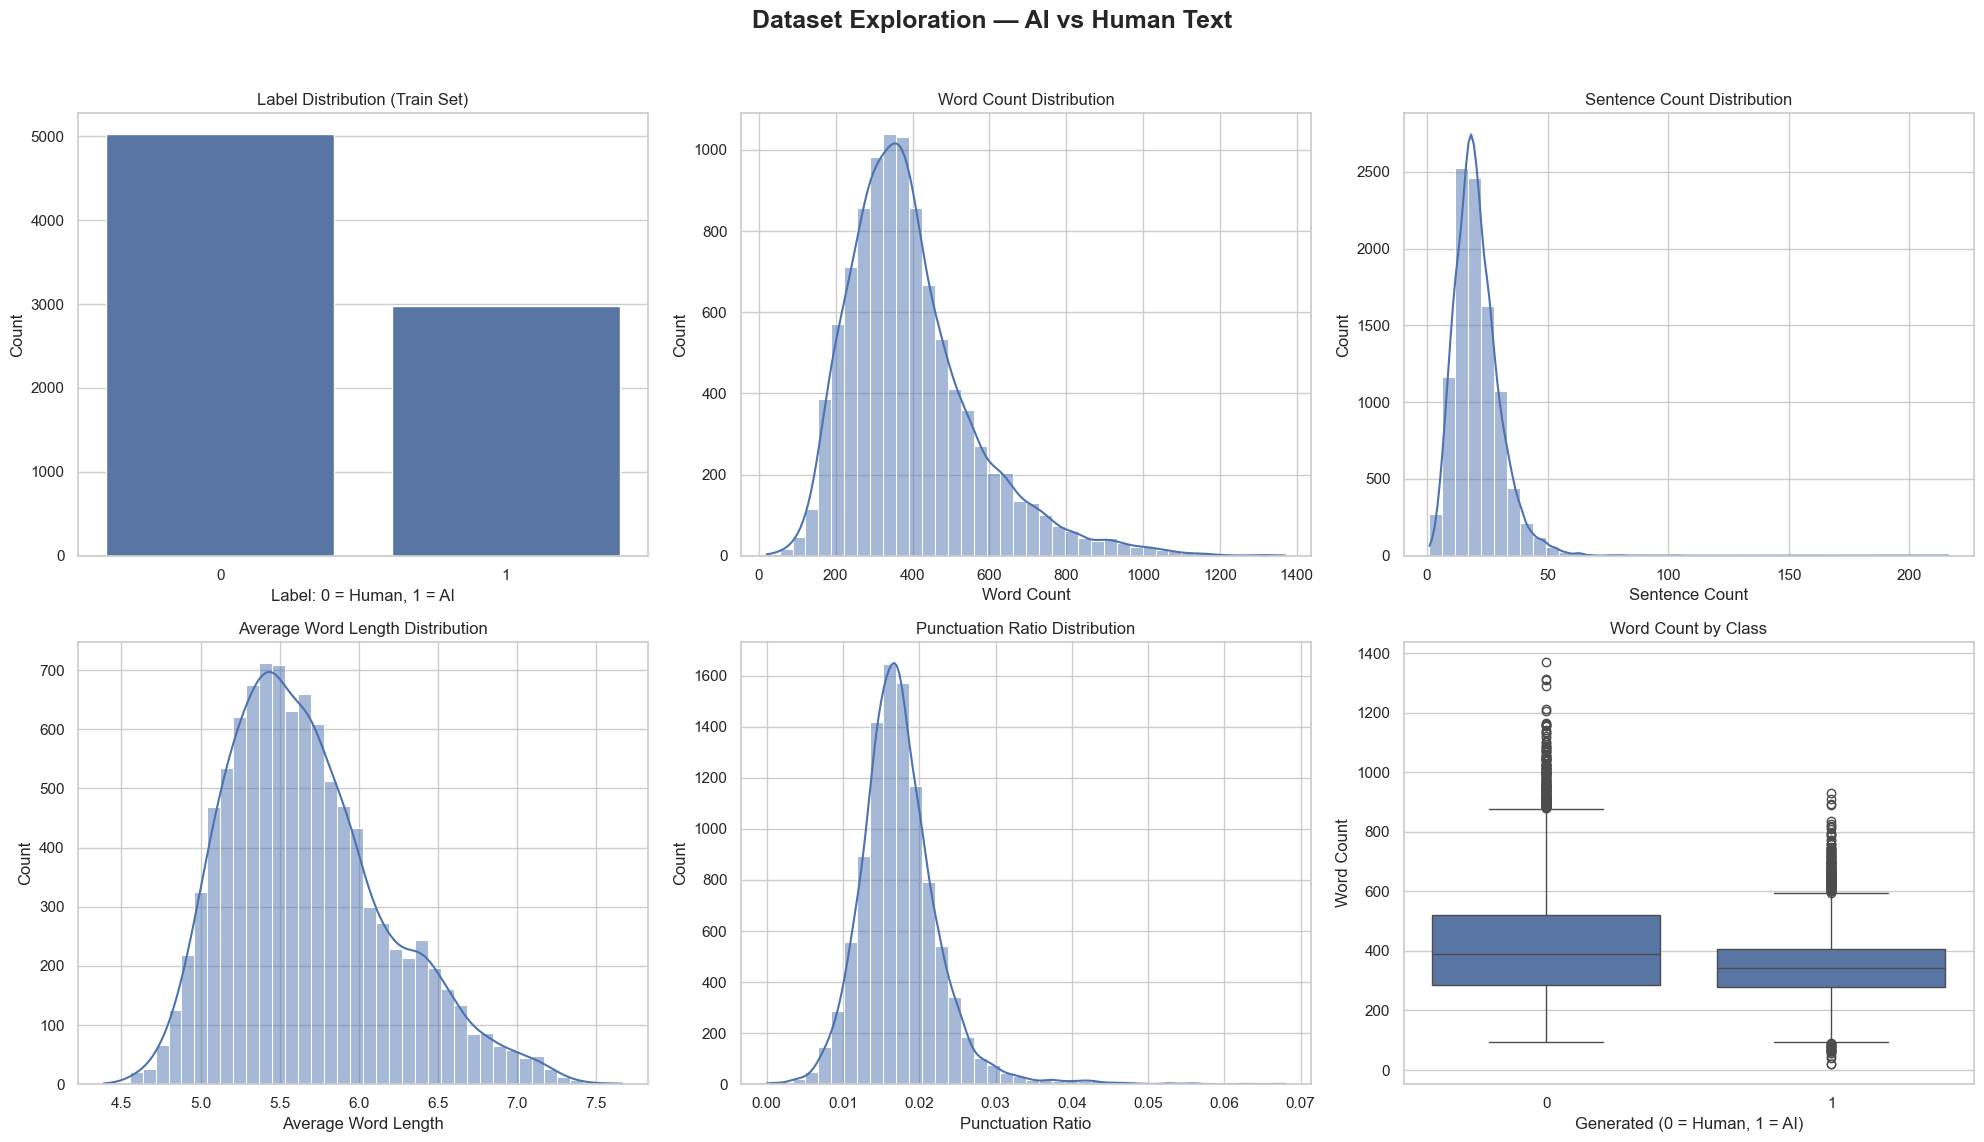

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")     # modern clean theme
sns.set_palette("deep")

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("Dataset Exploration — AI vs Human Text", fontsize=18, fontweight="bold")

# Train Label Distribution
sns.countplot(x=y_train, ax=axes[0,0])
axes[0,0].set_title("Label Distribution (Train Set)")
axes[0,0].set_xlabel("Label: 0 = Human, 1 = AI")
axes[0,0].set_ylabel("Count")

# Word Count Distribution
sns.histplot(df["word_count"], bins=40, kde=True, ax=axes[0,1])
axes[0,1].set_title("Word Count Distribution")
axes[0,1].set_xlabel("Word Count")

# Sentence Count Distribution
sns.histplot(df["sentence_count"], bins=40, kde=True, ax=axes[0,2])
axes[0,2].set_title("Sentence Count Distribution")
axes[0,2].set_xlabel("Sentence Count")

# Avg Word Length Distribution
sns.histplot(df["avg_word_len"], bins=40, kde=True, ax=axes[1,0])
axes[1,0].set_title("Average Word Length Distribution")
axes[1,0].set_xlabel("Average Word Length")

# Punctuation Ratio Distribution
sns.histplot(df["punct_ratio"], bins=40, kde=True, ax=axes[1,1])
axes[1,1].set_title("Punctuation Ratio Distribution")
axes[1,1].set_xlabel("Punctuation Ratio")

# Word Count by Class (Human vs AI)
sns.boxplot(x=df["generated"], y=df["word_count"], ax=axes[1,2])
axes[1,2].set_title("Word Count by Class")
axes[1,2].set_xlabel("Generated (0 = Human, 1 = AI)")
axes[1,2].set_ylabel("Word Count")

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()


In [15]:
# Map existing constants to model variables
max_len = MAX_LEN
vocab_size = MAX_NUM_WORDS

print("max_len =", max_len)
print("vocab_size =", vocab_size)


max_len = 500
vocab_size = 20000


In [16]:
# Unified Hyperparameter Set 

embed_dim = 64          # same embedding dimension for all models
dropout_rate = 0.3      # consistent dropout rate
dense_units = 64        # consistent Dense layer size
lstm_units = 128        # consistent LSTM size
filters = 128           # consistent CNN/GCU filters
num_heads = 4           # transformer attention heads
ff_dim = 128            # transformer feed-forward dimension


## Assignment 4-2: Implementation of Deep Learning Model (8 points)



### Bidirectional LSTM Model

In [17]:
# Modeling
embed_dim = 64
lstm_units = 128

input_text = Input(shape=(max_len,))
x = Embedding(input_dim=vocab_size, output_dim=embed_dim)(input_text)
x = Bidirectional(LSTM(lstm_units, return_sequences=False))(x)
x = Dropout(0.4)(x)
output = Dense(1, activation='sigmoid')(x)

model_lstm = Model(inputs=input_text, outputs=output)

model_lstm.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model_lstm.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 500, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       197,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,477,889 (5.64 MB)

 Trainable params: 1,477,889 (5.64 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Training

early_stop = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

history_lstm, time_lstm = train_with_timer(
    model_lstm,
    X_text_train,
    y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 236s 1s/step - accuracy: 0.7956 - loss: 0.4589 - val_accuracy: 0.9400 - val_loss: 0.1905
Epoch 2/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 251s 1s/step - accuracy: 0.9069 - loss: 0.2456 - val_accuracy: 0.8037 - val_loss: 0.4742
Epoch 3/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 269s 1s/step - accuracy: 0.9200 - loss: 0.2369 - val_accuracy: 0.9525 - val_loss: 0.1461
Epoch 4/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 221s 926ms/step - accuracy: 0.9758 - loss: 0.0804 - val_accuracy: 0.9525 - val_loss: 0.1347
Epoch 5/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 201s 919ms/step - accuracy: 0.9877 - loss: 0.0467 - val_accuracy: 0.9600 - val_loss: 0.1200

Training time: 1178.38 seconds


In [19]:
# Evaluation on test set
lstm_loss, lstm_acc = model_lstm.evaluate(X_text_test, y_test, verbose=0)
print(f"LSTM Test Accuracy: {lstm_acc:.4f}")


LSTM Test Accuracy: 0.9570


63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 233ms/step


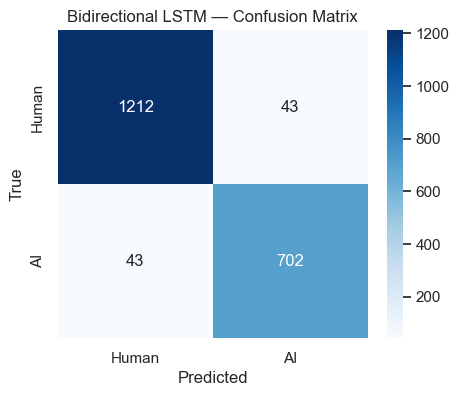


Classification Report:

              precision    recall  f1-score   support

       Human       0.97      0.97      0.97      1255
          AI       0.94      0.94      0.94       745

    accuracy                           0.96      2000
   macro avg       0.95      0.95      0.95      2000
weighted avg       0.96      0.96      0.96      2000



In [20]:
# CONFUSION MATRIX + REPORT + HEATMAP for Bidirectional LSTM

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predict
y_pred_prob = model_lstm.predict(X_text_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
labels = ["Human", "AI"]

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title("Bidirectional LSTM — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=labels))


### 1D-CNN Model

In [21]:
# Modeling
from tensorflow.keras.layers import Concatenate

# Hyperparameters
embed_dim = 64
filters = 128
filter_sizes = [3, 4, 5]

input_text = Input(shape=(MAX_LEN,))

# Embedding layer
embed = Embedding(
    input_dim=MAX_NUM_WORDS,
    output_dim=embed_dim
)(input_text)

# Parallel CNN branches
cnn_blocks = []
for f in filter_sizes:
    x = Conv1D(filters, f, activation='relu')(embed)
    x = GlobalMaxPooling1D()(x)
    cnn_blocks.append(x)

# Concatenate all filters
x = Concatenate()(cnn_blocks)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

model_cnn = Model(input_text, output)
model_cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model_cnn.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 500)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 500, 64)   │  1,280,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 498, 128)  │     24,704 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 497, 128)  │     32,896 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 496, 128)  │     41,088 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 384)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 384)       │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        385 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,379,073 (5.26 MB)

 Trainable params: 1,379,073 (5.26 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Training

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history_cnn, time_cnn = train_with_timer(
    model_cnn,
    X_text_train,
    y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)




Epoch 1/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 49s 224ms/step - accuracy: 0.8322 - loss: 0.3466 - val_accuracy: 0.9494 - val_loss: 0.1452
Epoch 2/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 81s 220ms/step - accuracy: 0.9675 - loss: 0.0932 - val_accuracy: 0.9762 - val_loss: 0.0713
Epoch 3/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 45s 222ms/step - accuracy: 0.9883 - loss: 0.0387 - val_accuracy: 0.9831 - val_loss: 0.0526
Epoch 4/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 75s 186ms/step - accuracy: 0.9972 - loss: 0.0151 - val_accuracy: 0.9781 - val_loss: 0.0649
Epoch 5/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 48s 242ms/step - accuracy: 0.9986 - loss: 0.0074 - val_accuracy: 0.9794 - val_loss: 0.0504

Training time: 331.90 seconds


In [23]:
# Evaluate on test data
cnn_loss, cnn_acc = model_cnn.evaluate(X_text_test, y_test)
print("\nCNN Test Accuracy:", round(cnn_acc, 4))

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9810 - loss: 0.0566

CNN Test Accuracy: 0.981


63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step


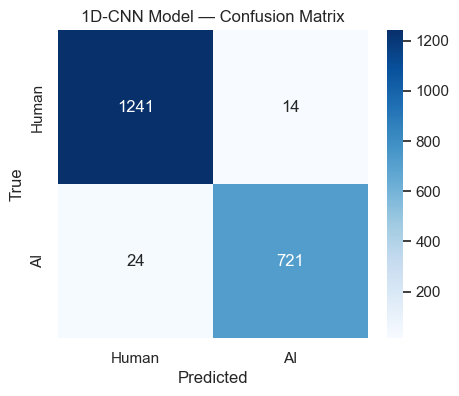


Classification Report:

              precision    recall  f1-score   support

       Human       0.98      0.99      0.98      1255
          AI       0.98      0.97      0.97       745

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.98      0.98      0.98      2000



In [24]:
# CONFUSION MATRIX + REPORT + HEATMAP for 1D-CNN Model

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predict
y_pred_prob = model_cnn.predict(X_text_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
labels = ["Human", "AI"]

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title("1D-CNN Model — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=labels))


## GCU MODELING (Gated Convolution Unit)

In [25]:
# Modeling

from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D, Multiply
from tensorflow.keras.layers import Multiply

embed_dim = 64
filters = 128
kernel_size = 3

# Input
input_text = Input(shape=(max_len,), name="text_input")

# Embedding layer
x = Embedding(
    input_dim=vocab_size, 
    output_dim=embed_dim
)(input_text)

# ---- GCU Block ----
# Linear convolution
conv_linear = Conv1D(
    filters=filters, 
    kernel_size=kernel_size, 
    padding="same"
)(x)

# Gate convolution (sigmoid)
conv_gate = Conv1D(
    filters=filters, 
    kernel_size=kernel_size,
    padding="same",
    activation="sigmoid"
)(x)

# Gated output
gcu_output = Multiply()([conv_linear, conv_gate])

# Pooling
x = GlobalMaxPooling1D()(gcu_output)

# Dense layers
x = Dropout(0.3)(x)
x = Dense(64, activation="relu")(x)
x = Dropout(0.3)(x)

# Output
output = Dense(1, activation="sigmoid")(x)

# Build model
model_gcu = Model(inputs=input_text, outputs=output)

model_gcu.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model_gcu.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 500)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 500, 64)   │  1,280,000 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 500, 128)  │     24,704 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 500, 128)  │     24,704 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 500, 128)  │          0 │ conv1d_3[0][0],   │
│                     │                   │            │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ multiply[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         65 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,337,729 (5.10 MB)

 Trainable params: 1,337,729 (5.10 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# Training

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history_gcu, time_gcu = train_with_timer(
    model_gcu,
    X_text_train,
    y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)



Epoch 1/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 25s 111ms/step - accuracy: 0.7969 - loss: 0.4164 - val_accuracy: 0.9413 - val_loss: 0.1561
Epoch 2/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 22s 111ms/step - accuracy: 0.9595 - loss: 0.1192 - val_accuracy: 0.9781 - val_loss: 0.0674
Epoch 3/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 22s 112ms/step - accuracy: 0.9847 - loss: 0.0453 - val_accuracy: 0.9825 - val_loss: 0.0500
Epoch 4/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 38s 95ms/step - accuracy: 0.9923 - loss: 0.0252 - val_accuracy: 0.9856 - val_loss: 0.0473
Epoch 5/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 25s 127ms/step - accuracy: 0.9947 - loss: 0.0146 - val_accuracy: 0.9831 - val_loss: 0.0481

Training time: 132.64 seconds


In [27]:
# Evaluate model

gcu_loss, gcu_acc = model_gcu.evaluate(X_text_test, y_test, verbose=1)
print(f"GCU Model Test Accuracy: {gcu_acc:.4f}")


63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9775 - loss: 0.0686
GCU Model Test Accuracy: 0.9775


63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step


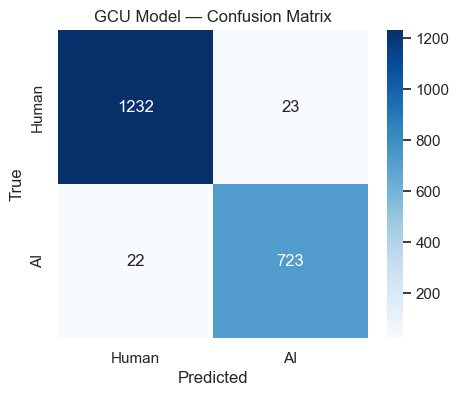


Classification Report:

              precision    recall  f1-score   support

       Human       0.98      0.98      0.98      1255
          AI       0.97      0.97      0.97       745

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.98      0.98      0.98      2000



In [28]:
# CONFUSION MATRIX + REPORT + HEATMAP for Hybrid (LSTM + Numeric Features)

from sklearn.metrics import confusion_matrix, classification_report

# Predictions
y_pred_prob = model_gcu.predict(X_text_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
labels = ["Human", "AI"]

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.title("GCU Model — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=labels))

### Hybrid LSTM + numeric feature model

In [29]:

# Modeling

# Hyperparameters
embed_dim = 64
lstm_units = 128

# Text input branch
input_text = Input(shape=(MAX_LEN,), name="text_input")
x1 = Embedding(input_dim=MAX_NUM_WORDS, output_dim=embed_dim)(input_text)
x1 = Bidirectional(LSTM(lstm_units, return_sequences=False))(x1)
x1 = Dropout(0.3)(x1)

# Numeric input branch
input_num = Input(shape=(X_num_train.shape[1],), name="num_input")
x2 = Dense(64, activation='relu')(input_num)
x2 = Dropout(0.3)(x2)

# Merge branches
merged = Concatenate()([x1, x2])
x = Dense(64, activation='relu')(merged)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

# Define and compile
model_hybrid = Model(inputs=[input_text, input_num], outputs=output)
model_hybrid.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model_hybrid.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 500)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 500, 64)   │  1,280,000 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_input           │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 256)       │    197,632 │ embedding_3[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │        384 │ num_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 256)       │          0 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 320)       │          0 │ dropout_4[0][0],  │
│ (Concatenate)       │                   │            │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │     20,544 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 64)        │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1)         │         65 │ dropout_6[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,498,625 (5.72 MB)

 Trainable params: 1,498,625 (5.72 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# Training

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history_hybrid, time_hybrid = train_with_timer(
    model_hybrid,
    [X_text_train, X_num_train],
    y_train,
    validation_data=([X_text_test, X_num_test], y_test),
    epochs=5,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)



Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 205s 788ms/step - accuracy: 0.8935 - loss: 0.2445 - val_accuracy: 0.9725 - val_loss: 0.0774
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 196s 762ms/step - accuracy: 0.9685 - loss: 0.0899 - val_accuracy: 0.9665 - val_loss: 0.1001
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 201s 806ms/step - accuracy: 0.9876 - loss: 0.0442 - val_accuracy: 0.9540 - val_loss: 0.1422

Training time: 603.22 seconds


In [31]:
# Evaluate model
hybrid_loss, hybrid_acc = model_hybrid.evaluate([X_text_test, X_num_test], y_test, verbose=1)
print(f"\nHybrid Model Test Accuracy: {hybrid_acc:.4f}")


63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 228ms/step - accuracy: 0.9725 - loss: 0.0774

Hybrid Model Test Accuracy: 0.9725


63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 239ms/step


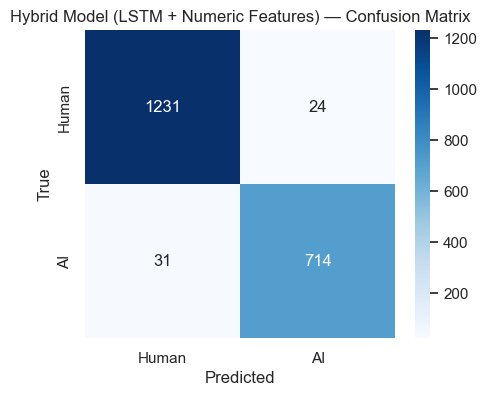


Classification Report:

              precision    recall  f1-score   support

       Human       0.98      0.98      0.98      1255
          AI       0.97      0.96      0.96       745

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000



In [32]:
# CONFUSION MATRIX + REPORT + HEATMAP for Hybrid (LSTM + Numeric Features)

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predict
y_pred_prob = model_hybrid.predict([X_text_test, X_num_test])
y_pred = (y_pred_prob > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
labels = ["Human", "AI"]

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title("Hybrid Model (LSTM + Numeric Features) — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=labels))


### Custom Transformer Encoder

In [33]:
# Modeling

# Hyperparameters
embed_dim = 64         # same as CNN/LSTM
num_heads = 4          # small, fair comparison
ff_dim = 128           # feed-forward layer size
dropout_rate = 0.3

# Input
text_input = Input(shape=(MAX_LEN,), name="text_input")

# Embedding
x = Embedding(
    input_dim=MAX_NUM_WORDS,
    output_dim=embed_dim
)(text_input)

# Transformer Encoder Block 

# Multi-head self-attention (FIXED key_dim)
attn_output = MultiHeadAttention(
    num_heads=num_heads,
    key_dim=embed_dim // num_heads
)(x, x)

# Add & Norm
attn_output = Add()([x, attn_output])
attn_output = LayerNormalization()(attn_output)

# Feed-forward network
ff = Dense(ff_dim, activation="relu")(attn_output)
ff = Dense(embed_dim)(ff)

# Add & Norm again
x = Add()([attn_output, ff])
x = LayerNormalization()(x)

# Global pooling
x = GlobalAveragePooling1D()(x)

# Dense head
x = Dropout(dropout_rate)(x)
x = Dense(64, activation="relu")(x)
x = Dropout(dropout_rate)(x)

# Output
output = Dense(1, activation="sigmoid")(x)

# Build model
model_transformer = Model(inputs=text_input, outputs=output)

model_transformer.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_transformer.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 500)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 500, 64)   │  1,280,000 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 500, 64)   │     16,640 │ embedding_4[0][0… │
│ (MultiHeadAttentio… │                   │            │ embedding_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 500, 64)   │          0 │ embedding_4[0][0… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 500, 64)   │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 500, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 500, 64)   │      8,256 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 500, 64)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 500, 64)   │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 64)        │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 64)        │      4,160 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 64)        │          0 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 1)         │         65 │ dropout_9[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,317,697 (5.03 MB)

 Trainable params: 1,317,697 (5.03 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# Training 

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history_trans, time_trans = train_with_timer(
    model_transformer,
    X_text_train,
    y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 86s 386ms/step - accuracy: 0.8733 - loss: 0.2762 - val_accuracy: 0.9719 - val_loss: 0.0821
Epoch 2/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 78s 392ms/step - accuracy: 0.9772 - loss: 0.0645 - val_accuracy: 0.9831 - val_loss: 0.0525
Epoch 3/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 83s 396ms/step - accuracy: 0.9961 - loss: 0.0173 - val_accuracy: 0.9856 - val_loss: 0.0459
Epoch 4/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 70s 352ms/step - accuracy: 0.9984 - loss: 0.0081 - val_accuracy: 0.9869 - val_loss: 0.0468
Epoch 5/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 77s 383ms/step - accuracy: 0.9970 - loss: 0.0092 - val_accuracy: 0.9819 - val_loss: 0.0631

Training time: 394.76 seconds


In [35]:
# Evaluate model

transformer_loss, transformer_acc = model_transformer.evaluate(X_text_test, y_test)
print("Custom Transformer Test Accuracy:", transformer_acc)


63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 114ms/step - accuracy: 0.9840 - loss: 0.0548
Custom Transformer Test Accuracy: 0.984000027179718


63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 118ms/step


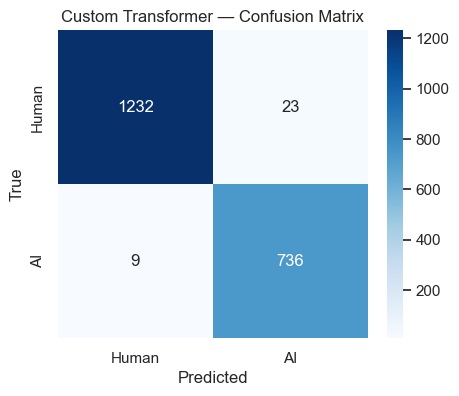


Classification Report:

              precision    recall  f1-score   support

       Human       0.99      0.98      0.99      1255
          AI       0.97      0.99      0.98       745

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.98      0.98      0.98      2000



In [36]:
# CONFUSION MATRIX + REPORT + HEATMAP for Custom Transformer

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predict
y_pred_prob = model_transformer.predict(X_text_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
labels = ["Human", "AI"]

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.title("Custom Transformer — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=labels))


## Summary for Analysis

In [45]:
# STORE ALL MODEL ACCURACIES & RUNTIMES HERE

acc_lstm = model_lstm.evaluate(X_text_test, y_test, verbose=0)[1]
acc_cnn = model_cnn.evaluate(X_text_test, y_test, verbose=0)[1]
acc_gcu = model_gcu.evaluate(X_text_test, y_test, verbose=0)[1]
acc_hybrid = model_hybrid.evaluate([X_text_test, X_num_test], y_test, verbose=0)[1]
acc_trans = model_transformer.evaluate(X_text_test, y_test, verbose=0)[1]


In [38]:
runtime_table = pd.DataFrame({
    "Model": ["BiLSTM", "1D-CNN", "GCU", "Hybrid", "Transformer"],
    "Runtime (sec)": [time_lstm, time_cnn, time_gcu, time_hybrid, time_trans],
    "Accuracy": [acc_lstm, acc_cnn, acc_gcu, acc_hybrid, acc_trans]
})

runtime_table

,Model,Runtime (sec),Accuracy
0,BiLSTM,1178.380515,0.9570
1,1D-CNN,331.903514,0.9810
2,GCU,132.641032,0.9775
3,Hybrid,603.219044,0.9725
4,Transformer,394.763144,0.9840


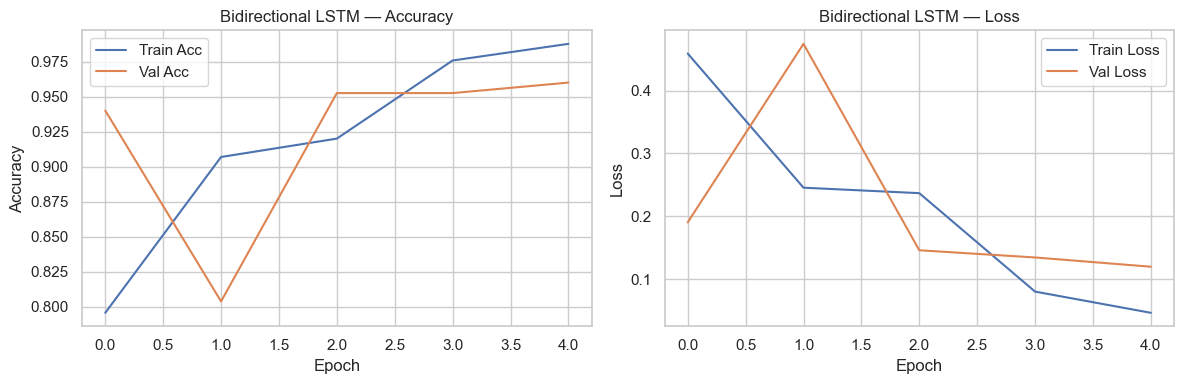

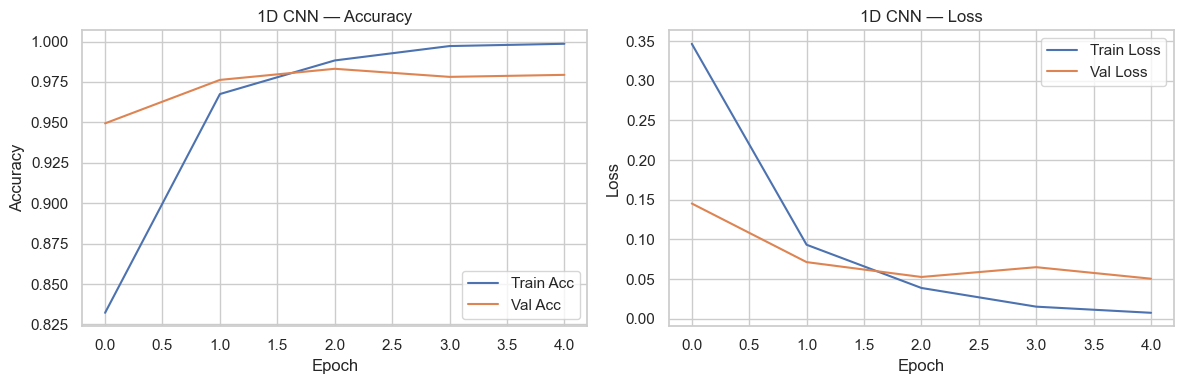

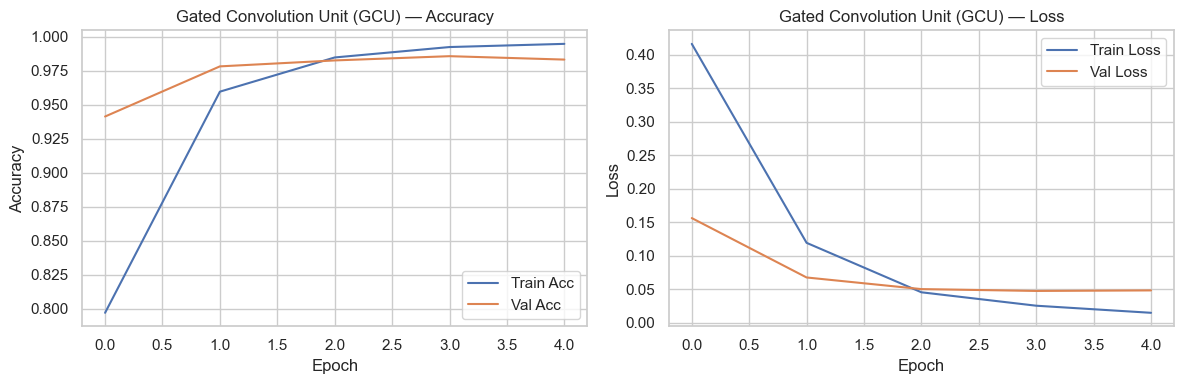

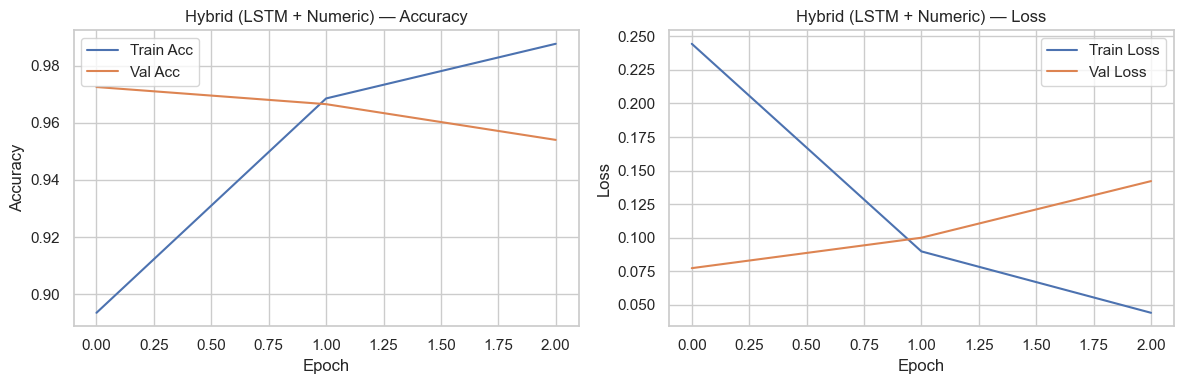

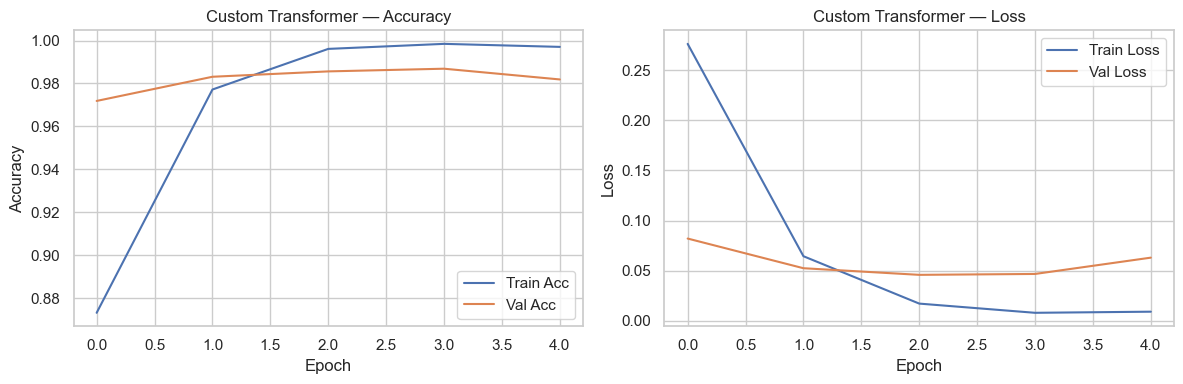

In [43]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # ---------- Accuracy (Left) ----------
    axes[0].plot(history.history['accuracy'], label='Train Acc')
    axes[0].plot(history.history['val_accuracy'], label='Val Acc')
    axes[0].set_title(title + " — Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()

    # ---------- Loss (Right) ----------
    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title(title + " — Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


# === PLOT TRAINING CURVES FOR ALL MODELS ===
plot_history(history_lstm, "Bidirectional LSTM")
plot_history(history_cnn, "1D CNN")
plot_history(history_gcu, "Gated Convolution Unit (GCU)")
plot_history(history_hybrid, "Hybrid (LSTM + Numeric)")
plot_history(history_trans, "Custom Transformer")


In [40]:
# COLLECT METRICS FOR ALL MODELS IN ONE PLACE 
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

metrics = {}

# 1) Bidirectional LSTM
y_pred_prob_lstm = model_lstm.predict(X_text_test)
y_pred_lstm = (y_pred_prob_lstm > 0.5).astype(int).ravel()
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
acc_lstm = (y_pred_lstm == y_test).mean()
metrics["Bidirectional LSTM"] = {"acc": acc_lstm, "cm": cm_lstm}

print("LSTM accuracy:", acc_lstm)
print("LSTM classification report:\n",
      classification_report(y_test, y_pred_lstm, target_names=["Human", "AI"]))


# 2) 1D-CNN
y_pred_prob_cnn = model_cnn.predict(X_text_test)
y_pred_cnn = (y_pred_prob_cnn > 0.5).astype(int).ravel()
cm_cnn = confusion_matrix(y_test, y_pred_cnn)
acc_cnn = (y_pred_cnn == y_test).mean()
metrics["1D CNN"] = {"acc": acc_cnn, "cm": cm_cnn}

print("\nCNN accuracy:", acc_cnn)
print("CNN classification report:\n",
      classification_report(y_test, y_pred_cnn, target_names=["Human", "AI"]))


# 3) Hybrid (LSTM + Numeric Features)
y_pred_prob_hybrid = model_hybrid.predict([X_text_test, X_num_test])
y_pred_hybrid = (y_pred_prob_hybrid > 0.5).astype(int).ravel()
cm_hybrid = confusion_matrix(y_test, y_pred_hybrid)
acc_hybrid = (y_pred_hybrid == y_test).mean()
metrics["Hybrid (LSTM + Numeric)"] = {"acc": acc_hybrid, "cm": cm_hybrid}

print("\nHybrid accuracy:", acc_hybrid)
print("Hybrid classification report:\n",
      classification_report(y_test, y_pred_hybrid, target_names=["Human", "AI"]))


# 4) Custom Transformer Encoder
y_pred_prob_trans = model_transformer.predict(X_text_test)
y_pred_trans = (y_pred_prob_trans > 0.5).astype(int).ravel()
cm_trans = confusion_matrix(y_test, y_pred_trans)
acc_trans = (y_pred_trans == y_test).mean()
metrics["Custom Transformer Encoder"] = {"acc": acc_trans, "cm": cm_trans}

print("\nTransformer accuracy:", acc_trans)
print("Transformer classification report:\n",
      classification_report(y_test, y_pred_trans, target_names=["Human", "AI"]))


# 5) Gated Convolution Unit (GCU)
y_pred_prob_gcu = model_gcu.predict(X_text_test)
y_pred_gcu = (y_pred_prob_gcu > 0.5).astype(int).ravel()
cm_gcu = confusion_matrix(y_test, y_pred_gcu)
acc_gcu = (y_pred_gcu == y_test).mean()
metrics["Gated Convolution Unit (GCU)"] = {"acc": acc_gcu, "cm": cm_gcu}

print("\nGCU accuracy:", acc_gcu)
print("GCU classification report:\n",
      classification_report(y_test, y_pred_gcu, target_names=["Human", "AI"]))


63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 215ms/step
LSTM accuracy: 0.957
LSTM classification report:
               precision    recall  f1-score   support

       Human       0.97      0.97      0.97      1255
          AI       0.94      0.94      0.94       745

    accuracy                           0.96      2000
   macro avg       0.95      0.95      0.95      2000
weighted avg       0.96      0.96      0.96      2000

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step

CNN accuracy: 0.981
CNN classification report:
               precision    recall  f1-score   support

       Human       0.98      0.99      0.98      1255
          AI       0.98      0.97      0.97       745

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.98      0.98      0.98      2000

63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 214ms/step

Hybrid accuracy: 0.9725
Hybrid classification report:
               precision    recall  f1-score   support

       Human

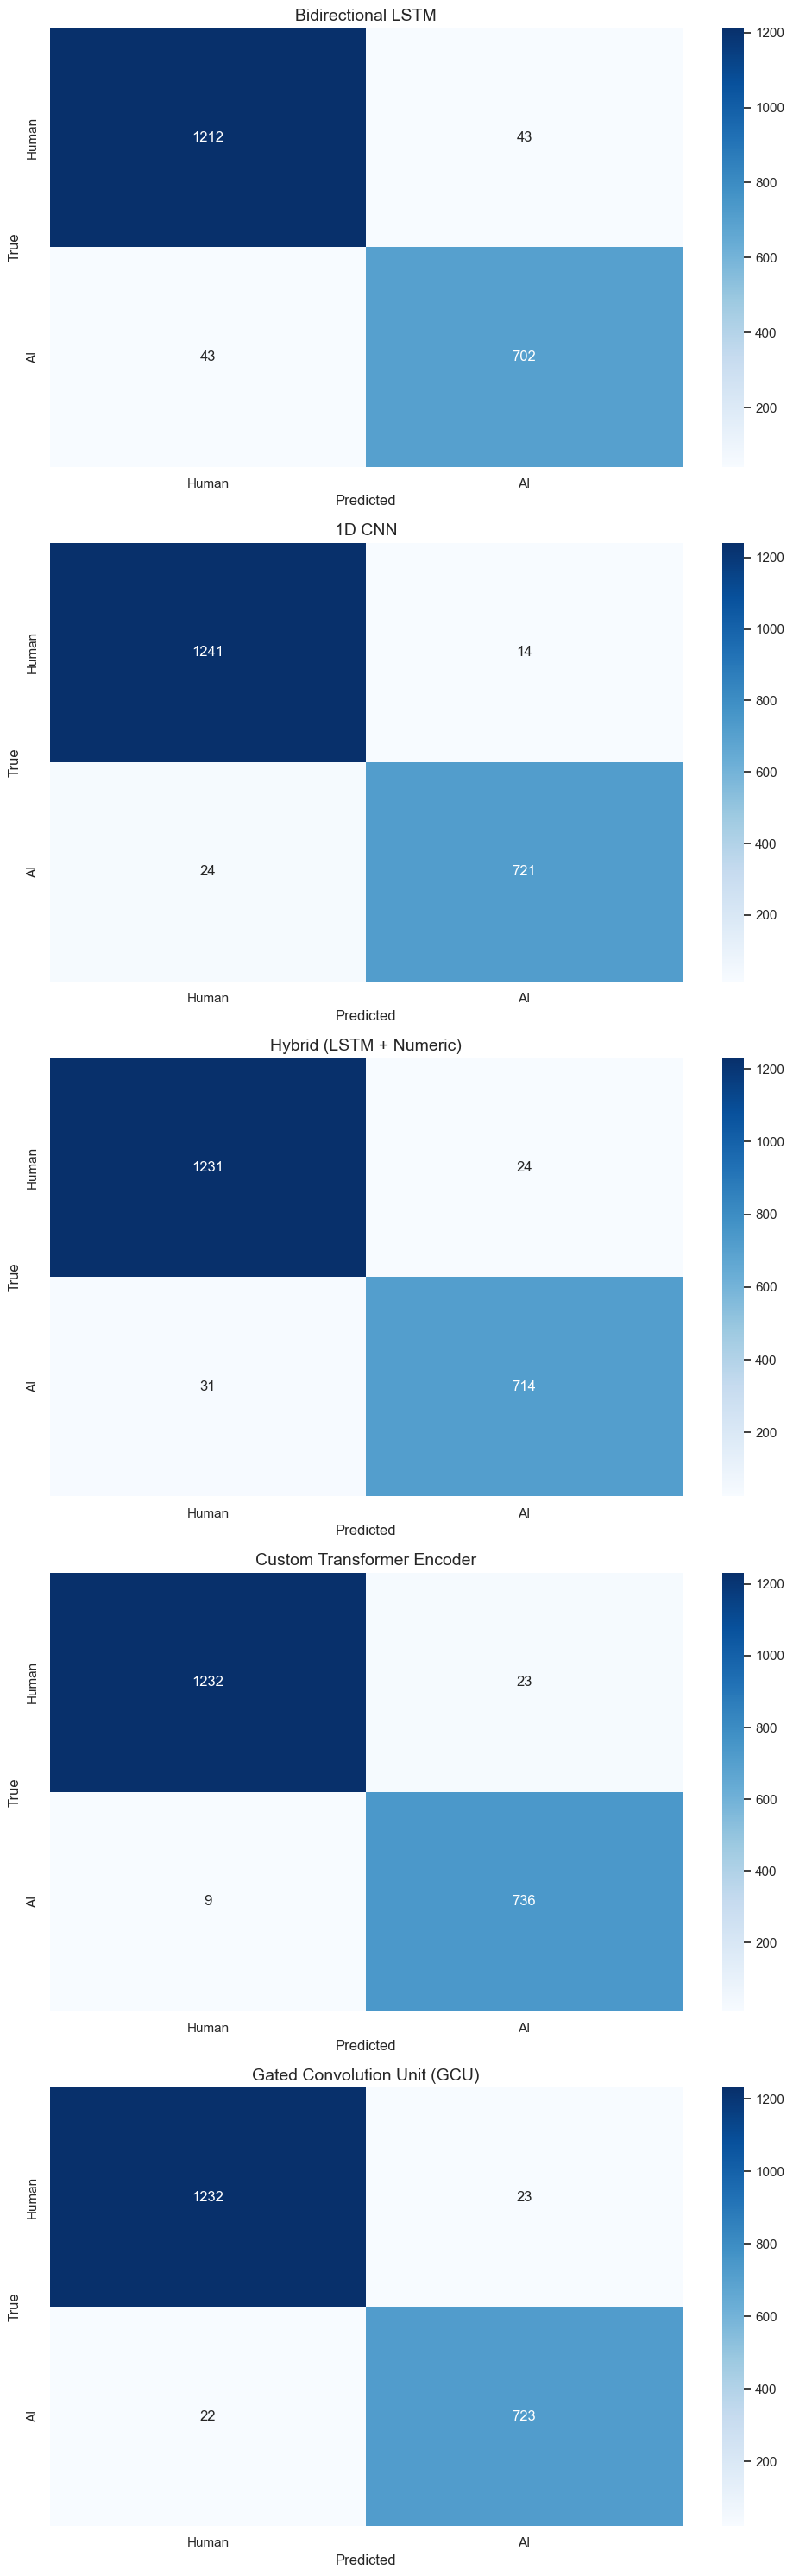

In [48]:
plt.figure(figsize=(10, 30))  # Taller figure for 5 rows

cm_dict = {
    "Bidirectional LSTM": cm_lstm,
    "1D CNN": cm_cnn,
    "Hybrid (LSTM + Numeric)": cm_hybrid,
    "Custom Transformer Encoder": cm_trans,
    "Gated Convolution Unit (GCU)": cm_gcu
}

for i, (name, cm) in enumerate(cm_dict.items(), 1):
    plt.subplot(len(cm_dict), 1, i)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Human", "AI"],
                yticklabels=["Human", "AI"])
    plt.title(name, fontsize=14)
    plt.xlabel("Predicted")
    plt.ylabel("True")

plt.tight_layout()
plt.show()


In [46]:
cm_dict = {
    "Bidirectional LSTM": cm_lstm,
    "1D CNN": cm_cnn,
    "Hybrid (LSTM + Numeric)": cm_hybrid,
    "Custom Transformer Encoder": cm_trans,
    "Gated Convolution Unit (GCU)": cm_gcu
}

for name, cm in cm_dict.items():
    print(f"\n{name} Confusion Matrix:")
    print(cm)



Bidirectional LSTM Confusion Matrix:
[[1212   43]
 [  43  702]]

1D CNN Confusion Matrix:
[[1241   14]
 [  24  721]]

Hybrid (LSTM + Numeric) Confusion Matrix:
[[1231   24]
 [  31  714]]

Custom Transformer Encoder Confusion Matrix:
[[1232   23]
 [   9  736]]

Gated Convolution Unit (GCU) Confusion Matrix:
[[1232   23]
 [  22  723]]


In [42]:
import pandas as pd

# Build a dataframe of model accuracies
accuracy_table = pd.DataFrame({
    "Model": list(metrics.keys()),
    "Accuracy": [metrics[m]["acc"] for m in metrics]
})

# Sort by accuracy (highest first) – optional
accuracy_table = accuracy_table.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

accuracy_table


,Model,Accuracy
0,Custom Transformer Encoder,0.9840
1,1D CNN,0.9810
2,Gated Convolution Unit (GCU),0.9775
3,Hybrid (LSTM + Numeric),0.9725
4,Bidirectional LSTM,0.9570


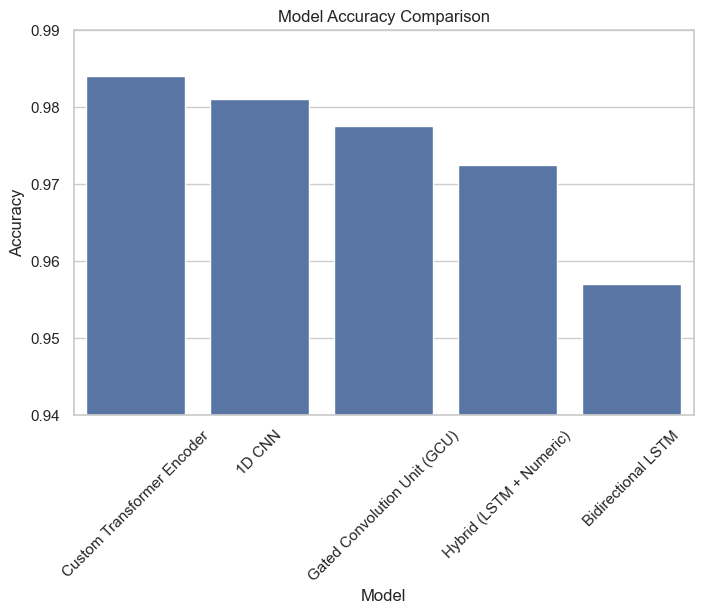

In [ ]:
# plt.figure(figsize=(8,5))

plt.figure(figsize=(8,5))
sns.barplot(data=accuracy_table, x="Model", y="Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.94, 0.99)
plt.xticks(rotation=45)
plt.show()


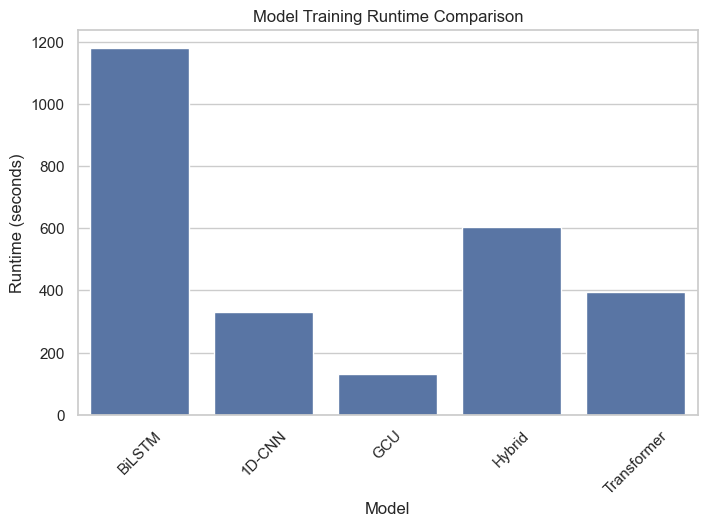

In [50]:
# Runtime Comparison

plt.figure(figsize=(8,5))
sns.barplot(data=runtime_table, x="Model", y="Runtime (sec)")
plt.title("Model Training Runtime Comparison")
plt.ylabel("Runtime (seconds)")
plt.xticks(rotation=45)
plt.show()


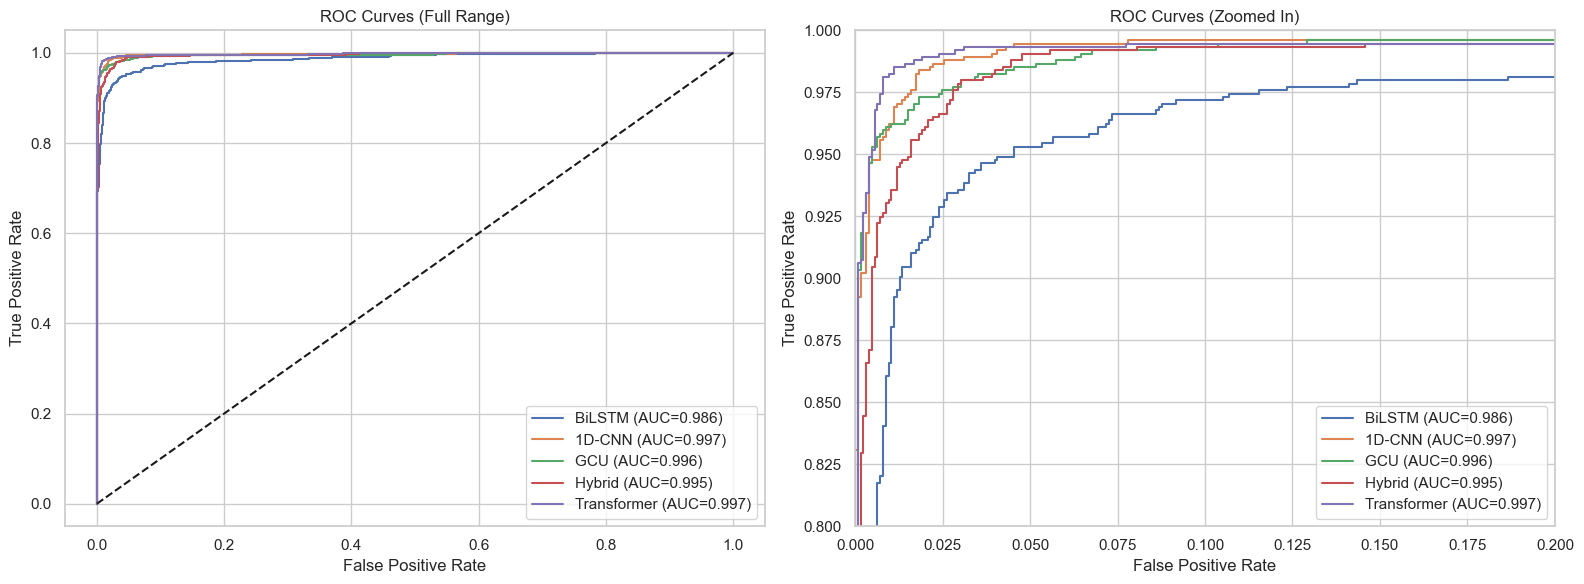

In [53]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

model_probs = {
    "BiLSTM": y_pred_prob_lstm,
    "1D-CNN": y_pred_prob_cnn,
    "GCU": y_pred_prob_gcu,
    "Hybrid": y_pred_prob_hybrid,
    "Transformer": y_pred_prob_trans
}

plt.figure(figsize=(16,6))

plt.subplot(1,2,1)
for name, preds in model_probs.items():
    fpr, tpr, _ = roc_curve(y_test, preds)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.title("ROC Curves (Full Range)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")

plt.subplot(1,2,2)
for name, preds in model_probs.items():
    fpr, tpr, _ = roc_curve(y_test, preds)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlim(0, 0.20)   
plt.ylim(0.80, 1.00) 
plt.title("ROC Curves (Zoomed In)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()


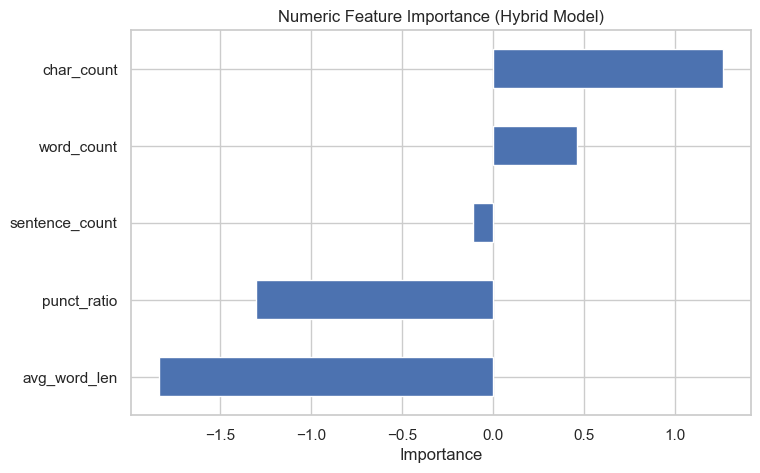

In [54]:
import numpy as np

weights = model_hybrid.layers[4].get_weights()[0].sum(axis=1)  # Dense weights from numeric branch
feature_importance = pd.Series(weights, index=num_cols)

feature_importance.sort_values().plot(kind='barh', figsize=(8,5))
plt.title("Numeric Feature Importance (Hybrid Model)")
plt.xlabel("Importance")
plt.show()


## Assignment 4-3 – Analysis of Results

In this part of the assignment, I compared five different deep learning models for detecting whether a piece of text was written by a human or generated by AI. I used the same dataset, preprocessing steps, tokenizer, and hyperparameters for all the models to make the comparison fair. The models I tested were: Bidirectional LSTM, 1D CNN, Gated Convolution Unit (GCU), Hybrid (LSTM + Numeric Features), and a Custom Transformer Encoder.

- **Hyperparameter Summary of Implemented Deep Learning Models**

| Hyperparameter        | BiLSTM | 1D-CNN | GCU | Hybrid | Transformer |
|-----------------------|--------|--------|-----|--------|-------------|
| **Embedding Dim**     | 64     | 64     | 64  | 64     | 64          |
| **Sequence Length**   | 500    | 500    | 500 | 500    | 500         |
| **LSTM Units**        | 128    | –      | –   | 128    | –           |
| **CNN Filters**       | –      | 128    | 128 (linear + gated) | – | – |
| **Kernel Sizes**      | –      | [3, 4, 5] | 3 | – | – |
| **Dropout**           | 0.3    | 0.3    | 0.3 | 0.3    | 0.3         |
| **Dense Units**       | 64     | 64     | 64  | 64     | 64          |
| **Attention Heads**   | –      | –      | –   | –      | 4           |
| **FFN Dim**           | –      | –      | –   | –      | 128         |
| **Batch Size**        | 32     | 32     | 32  | 32     | 32          |
| **Epochs**            | 5      | 5      | 5   | 5      | 5           |
| **Optimizer**         | Adam   | Adam   | Adam| Adam   | Adam        |
| **Learning Rate**     | 0.001  | 0.001  | 0.001 | 0.001 | 0.001      |

- **Combined Performance Summary of All Models**

| Model | Runtime (sec) | Accuracy | Precision (Human) | Recall (Human) | F1 (Human) | Precision (AI) | Recall (AI) | F1 (AI) |
|-------|---------------|----------|--------------------|----------------|------------|----------------|-------------|---------|
| **BiLSTM** | 1178.38 | 0.9570 | 0.97 | 0.97 | 0.97 | 0.94 | 0.94 | 0.94 |
| **1D-CNN** | 331.90 | 0.9810 | 0.98 | 0.99 | 0.98 | 0.98 | 0.97 | 0.97 |
| **GCU** | 132.64 | 0.9775 | 0.98 | 0.98 | 0.98 | 0.97 | 0.97 | 0.97 |
| **Hybrid (LSTM + Numeric)** | 603.22 | 0.9725 | 0.98 | 0.98 | 0.98 | 0.97 | 0.96 | 0.96 |
| **Transformer** | 394.76 | 0.9840 | 0.99 | 0.98 | 0.99 | 0.97 | 0.99 | 0.98 |


### Learning Results

All five models performed well overall, but their accuracy levels were clearly different. The results ranged from 0.957 accuracy for BiLSTM to 0.984 accuracy for the Transformer model.

Here is the ranking:

1. Custom Transformer Encoder — 0.984

2. 1D-CNN — 0.981

3. GCU — 0.9775

4. Hybrid (LSTM + Numeric) — 0.9725

5. Bidirectional LSTM — 0.957

The confusion matrices also supported these findings. The Transformer had the fewest errors, especially for identifying AI-generated text. The CNN and GCU also showed strong performance with relatively low misclassification counts. The LSTM model had the highest number of false predictions.

### How the Methods Worked

Each model behaved differently because of how the architecture processes sequences:

**Bidirectional LSTM**

This model was the slowest to train and the least accurate. LSTMs process text one step at a time, so long sequences (500 tokens in this case) are harder for them to handle. The training curves showed some overfitting and the model didn’t generalize as well as the others.

**1D-CNN**

The CNN performed extremely well and trained very fast. It captures local patterns (like n-grams), which are very helpful in detecting writing style differences between humans and AI. Its precision and recall were consistently high for both classes.

**Gated Convolution Unit (GCU)**

The GCU model was also fast and stable. The gating mechanism helped the model filter out less relevant information. It performed slightly lower than the CNN but was still strong, reaching 0.9775 accuracy.

**Hybrid (LSTM + Numeric Features)**

This model mixed the text features from an LSTM with numeric features like word count, average word length, sentence count, and punctuation ratio. It started with a high accuracy but overfitted after a few epochs. The numeric features helped but did not push the model above the CNN or Transformer.

**Custom Transformer Encoder**

This was the best-performing model. Transformers handle long sequences much better because they use self-attention instead of sequential processing. The model trained smoothly, validation accuracy stayed high, and the confusion matrix showed the fewest errors among all models.

### How Well the Models Worked

All models were able to separate human-written and AI-generated text quite well. The F1-scores were high for both classes across all models. However:

- Human text was slightly easier to classify (higher recall across models).

- AI text had more variation, which caused slightly lower precision/recall in some models.

- Transformer and CNN handled both classes the best, showing strong balance.

- LSTM struggled the most, especially with misclassifying some AI texts as human.

The learning patterns matched what I expected based on how the architectures work.

### Areas for Development

Some improvements I noticed:

- Better regularization for LSTM and Hybrid models to reduce overfitting.

- More numeric features (like readability, POS tags, or sentence complexity) for the Hybrid model.

- Deeper architectures, especially for CNN or Transformer.

- Pretrained embeddings instead of random initialization.

- Tokenization improvements, such as using SentencePiece or subword-level tokens.

- Running more epochs with a learning rate scheduler might boost performance even more.

### How to Optimize

If I optimized the models further, I would try:

- Hyperparameter tuning (filters, attention heads, layers, etc.)

- Using pretrained Transformer models like RoBERTa

- Increasing embedding dimension

- Adding batch normalization layers

- Trying multiple Transformer blocks instead of one

- Using cosine learning rate schedules or warmup steps

These optimizations would likely improve both training stability and accuracy.

### Other Considerations

This assignment gave me a clearer picture of how different deep learning architectures behave on the same problem. I learned:

- LSTMs are good but not ideal for long sequences

- CNNs are surprisingly strong for text classification

- GCU adds interesting gating behavior

- Hybrid models can help but require strong feature engineering

- Transformers are without question the best architecture for modern NLP tasks

Overall, the results were consistent and logical. The assignment was challenging but I enjoyed building, training, and comparing multiple models in a controlled and fair way.